In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries loaded!")

✅ Libraries loaded!


In [2]:
df = pd.read_csv('../data/yield_df.csv')
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (28242, 8)

Columns: ['Unnamed: 0', 'Area', 'Item', 'Year', 'hg/ha_yield', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']


,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [3]:
print("=== Dataset Info ===")
print(df.info())
print("\n=== Missing Values ===")
print(df.isnull().sum())
print("\n=== Basic Stats ===")
print(df.describe())

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     28242 non-null  int64  
 1   Area                           28242 non-null  str    
 2   Item                           28242 non-null  str    
 3   Year                           28242 non-null  int64  
 4   hg/ha_yield                    28242 non-null  int64  
 5   average_rain_fall_mm_per_year  28242 non-null  float64
 6   pesticides_tonnes              28242 non-null  float64
 7   avg_temp                       28242 non-null  float64
dtypes: float64(3), int64(3), str(2)
memory usage: 1.7 MB
None

=== Missing Values ===
Unnamed: 0                       0
Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm

In [4]:
print("Unique Countries:", df['Area'].nunique())
print("Unique Crops:", df['Item'].nunique())
print("Year Range:", df['Year'].min(), "to", df['Year'].max())
print("\nTop 10 Crops:\n", df['Item'].value_counts().head(10))

Unique Countries: 101
Unique Crops: 10
Year Range: 1990 to 2013

Top 10 Crops:
 Item
Potatoes                4276
Maize                   4121
Wheat                   3857
Rice, paddy             3388
Soybeans                3223
Sorghum                 3039
Sweet potatoes          2890
Cassava                 2045
Yams                     847
Plantains and others     556
Name: count, dtype: int64


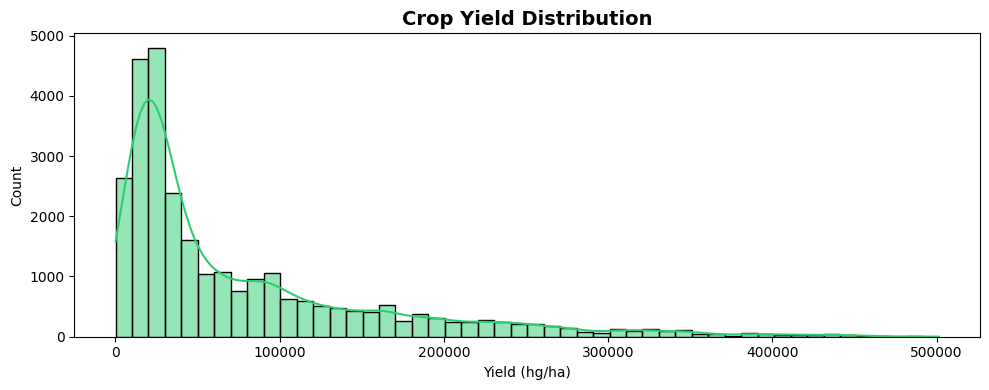

✅ Plot saved!


In [5]:
os.makedirs('../outputs', exist_ok=True)

plt.figure(figsize=(10, 4))
sns.histplot(df['hg/ha_yield'], bins=50, color='#2ecc71', kde=True)
plt.title('Crop Yield Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Yield (hg/ha)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../outputs/yield_distribution.png', dpi=150)
plt.show()
print("✅ Plot saved!")

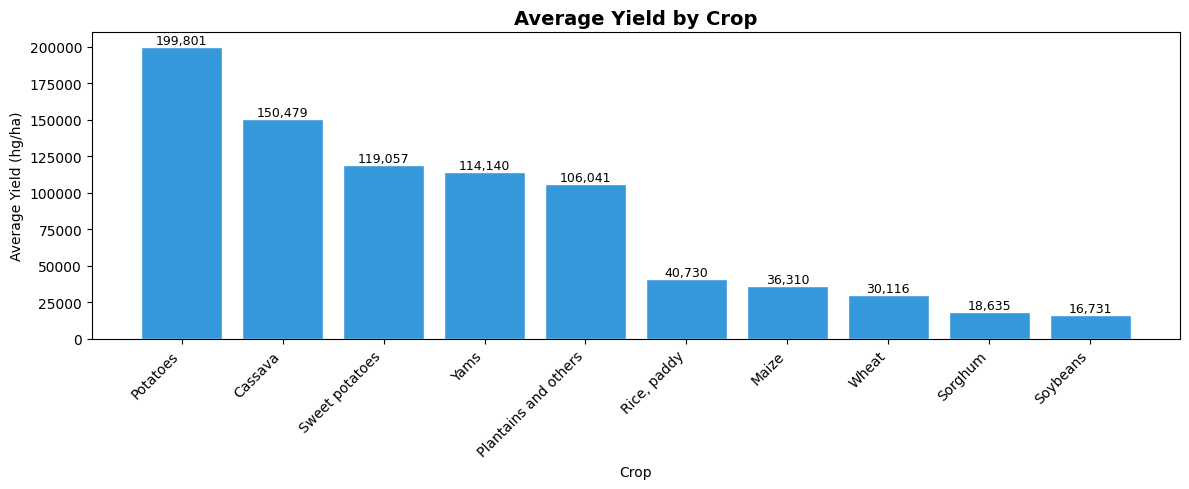

✅ Plot saved!


In [6]:
os.makedirs('../outputs', exist_ok=True)

crop_yield = df.groupby('Item')['hg/ha_yield'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
bars = plt.bar(crop_yield.index, crop_yield.values, color='#3498db', edgecolor='white')
plt.title('Average Yield by Crop', fontsize=14, fontweight='bold')
plt.xlabel('Crop')
plt.ylabel('Average Yield (hg/ha)')
plt.xticks(rotation=45, ha='right')
for bar, val in zip(bars, crop_yield.values):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
             f'{int(val):,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('../outputs/yield_by_crop.png', dpi=150)
plt.show()
print("✅ Plot saved!")

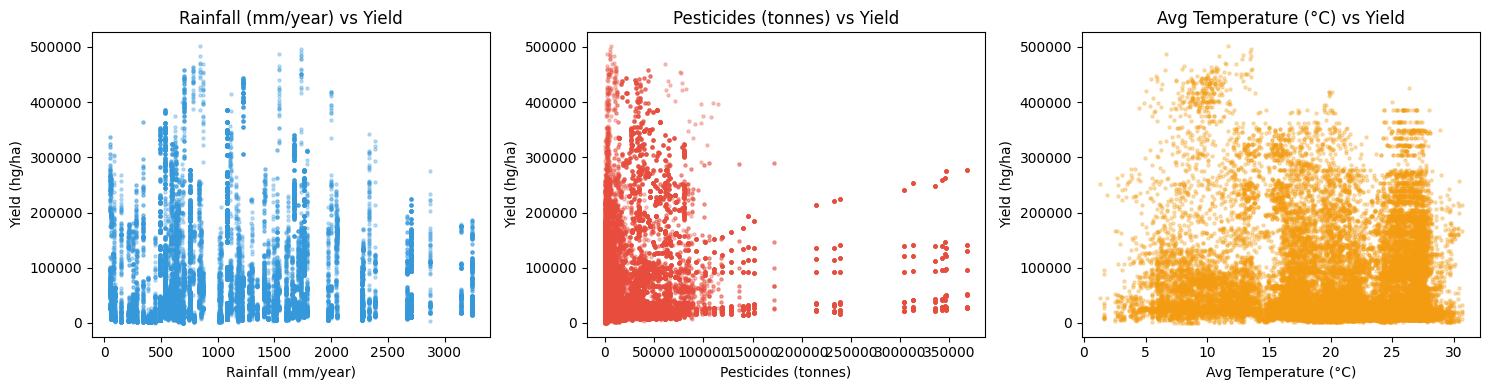

✅ Plot saved!


In [7]:
os.makedirs('../outputs', exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

features = ['average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']
colors = ['#3498db', '#e74c3c', '#f39c12']
labels = ['Rainfall (mm/year)', 'Pesticides (tonnes)', 'Avg Temperature (°C)']

for i, (feat, color, label) in enumerate(zip(features, colors, labels)):
    axes[i].scatter(df[feat], df['hg/ha_yield'], alpha=0.3, color=color, s=5)
    axes[i].set_xlabel(label)
    axes[i].set_ylabel('Yield (hg/ha)')
    axes[i].set_title(f'{label} vs Yield')

plt.tight_layout()
plt.savefig('../outputs/climate_vs_yield.png', dpi=150)
plt.show()
print("✅ Plot saved!")

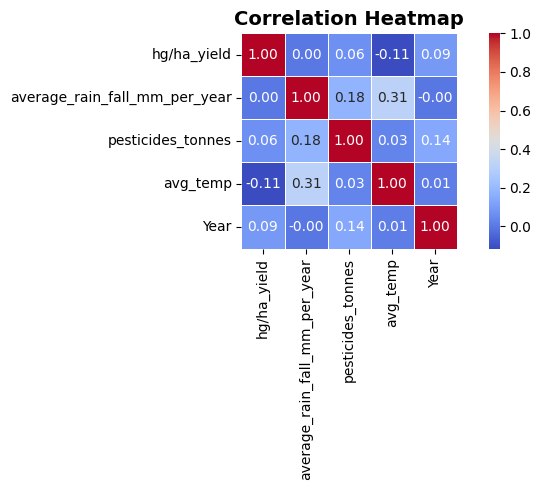

✅ Plot saved!


In [8]:
os.makedirs('../outputs', exist_ok=True)

plt.figure(figsize=(8, 5))
num_cols = ['hg/ha_yield', 'average_rain_fall_mm_per_year', 
            'pesticides_tonnes', 'avg_temp', 'Year']
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/correlation_heatmap.png', dpi=150)
plt.show()
print("✅ Plot saved!")

In [9]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Unnamed column drop karo
df.drop('Unnamed: 0', axis=1, inplace=True)

# Label Encode categorical columns
le_area = LabelEncoder()
le_item = LabelEncoder()

df['Area_encoded'] = le_area.fit_transform(df['Area'])
df['Item_encoded'] = le_item.fit_transform(df['Item'])

# Features aur Target
X = df[['Area_encoded', 'Item_encoded', 'Year', 
        'average_rain_fall_mm_per_year', 
        'pesticides_tonnes', 'avg_temp']]
y = df['hg/ha_yield']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Preprocessing done!")
print(f"Train size: {X_train.shape}")
print(f"Test size:  {X_test.shape}")

✅ Preprocessing done!
Train size: (22593, 6)
Test size:  (5649, 6)


In [10]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)

rf_r2   = r2_score(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae  = mean_absolute_error(y_test, rf_pred)

print("=" * 45)
print("       RANDOM FOREST RESULTS")
print("=" * 45)
print(f"R² Score : {rf_r2:.4f}")
print(f"RMSE     : {rf_rmse:.2f}")
print(f"MAE      : {rf_mae:.2f}")
print("✅ Random Forest trained!")

       RANDOM FOREST RESULTS
R² Score : 0.9851
RMSE     : 10380.63
MAE      : 4202.15
✅ Random Forest trained!


In [11]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)
xgb_model.fit(X_train_scaled, y_train)
xgb_pred = xgb_model.predict(X_test_scaled)

xgb_r2   = r2_score(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_mae  = mean_absolute_error(y_test, xgb_pred)

print("=" * 45)
print("         XGBOOST RESULTS")
print("=" * 45)
print(f"R² Score : {xgb_r2:.4f}")
print(f"RMSE     : {xgb_rmse:.2f}")
print(f"MAE      : {xgb_mae:.2f}")
print("✅ XGBoost trained!")

         XGBOOST RESULTS
R² Score : 0.9644
RMSE     : 16068.63
MAE      : 9498.04
✅ XGBoost trained!


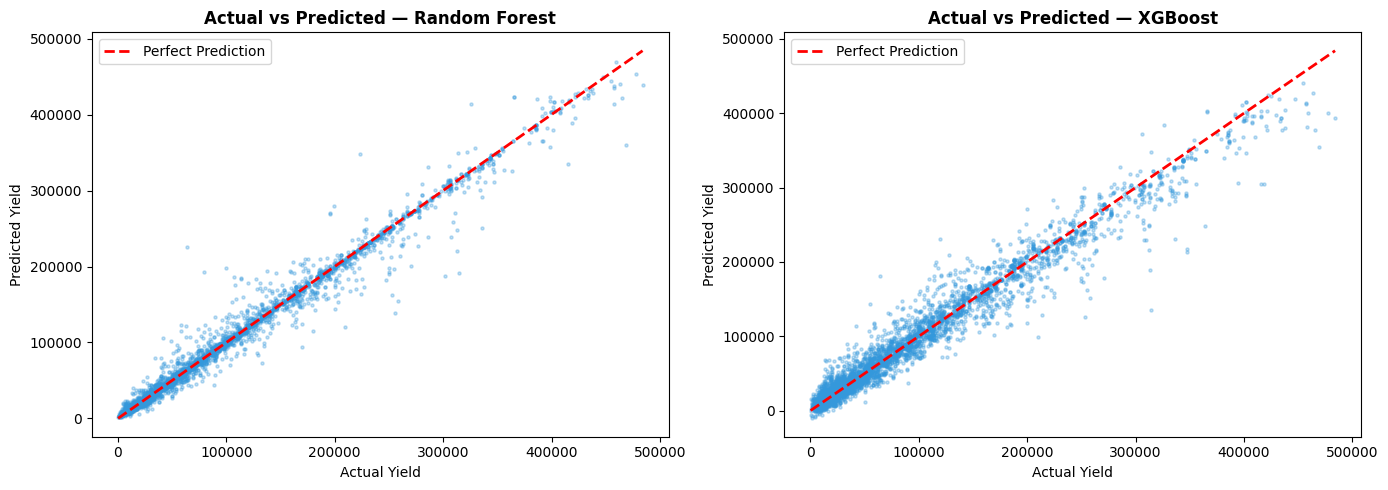

✅ Plot saved!


In [12]:
os.makedirs('../outputs', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pred, title in zip(axes,
                            [rf_pred, xgb_pred],
                            ['Random Forest', 'XGBoost']):
    ax.scatter(y_test, pred, alpha=0.3, s=5, color='#3498db')
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()],
            'r--', lw=2, label='Perfect Prediction')
    ax.set_xlabel('Actual Yield')
    ax.set_ylabel('Predicted Yield')
    ax.set_title(f'Actual vs Predicted — {title}', fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.savefig('../outputs/actual_vs_predicted.png', dpi=150)
plt.show()
print("✅ Plot saved!")

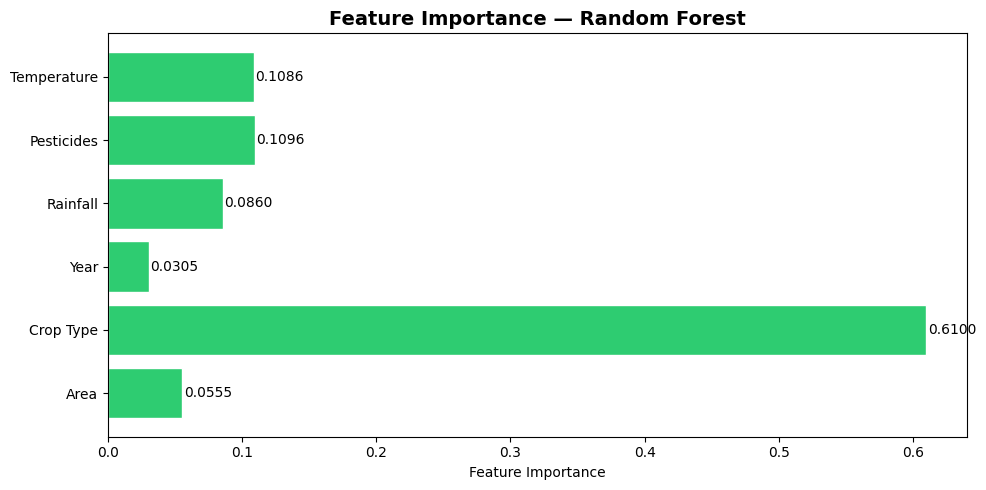

✅ Plot saved!


In [13]:
os.makedirs('../outputs', exist_ok=True)

feature_names = ['Area', 'Crop Type', 'Year', 
                 'Rainfall', 'Pesticides', 'Temperature']
importances = rf_model.feature_importances_

plt.figure(figsize=(10, 5))
bars = plt.barh(feature_names, importances, color='#2ecc71', edgecolor='white')
plt.xlabel('Feature Importance')
plt.title('Feature Importance — Random Forest', fontsize=14, fontweight='bold')
for bar, val in zip(bars, importances):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('../outputs/feature_importance.png', dpi=150)
plt.show()
print("✅ Plot saved!")

Background dataset has 22593 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=22593 when initializing the masker.
 99%|===================| 5582/5649 [00:41<00:00]        

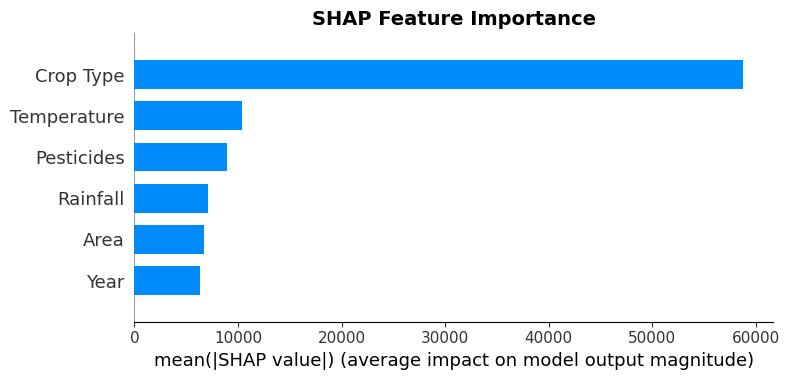

✅ SHAP plot saved!


In [14]:
import shap
os.makedirs('../outputs', exist_ok=True)

explainer = shap.Explainer(xgb_model, X_train_scaled)
shap_values = explainer(X_test_scaled)

plt.figure()
shap.summary_plot(shap_values, X_test_scaled,
                  feature_names=['Area', 'Crop Type', 'Year',
                                 'Rainfall', 'Pesticides', 'Temperature'],
                  plot_type='bar', show=False)
plt.title('SHAP Feature Importance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ SHAP plot saved!")

In [15]:
import joblib
os.makedirs('../models', exist_ok=True)

joblib.dump(rf_model, '../models/random_forest_model.pkl')
joblib.dump(xgb_model, '../models/xgboost_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump(le_area, '../models/label_encoder_area.pkl')
joblib.dump(le_item, '../models/label_encoder_item.pkl')

print("✅ All models saved!")

✅ All models saved!


In [16]:
print("=" * 50)
print("  CROP YIELD PREDICTION — FINAL RESULTS")
print("=" * 50)

print("\n📊 RANDOM FOREST:")
print(f"   R² Score : {rf_r2:.4f}")
print(f"   RMSE     : {rf_rmse:.2f}")
print(f"   MAE      : {rf_mae:.2f}")

print("\n📊 XGBOOST:")
print(f"   R² Score : {xgb_r2:.4f}")
print(f"   RMSE     : {xgb_rmse:.2f}")
print(f"   MAE      : {xgb_mae:.2f}")

print("\n🏆 BEST MODEL: Random Forest")
print(f"   R² = {rf_r2:.4f} (explains {rf_r2*100:.2f}% of variance)")

print("\n✅ Project Complete!")
print("=" * 50)

  CROP YIELD PREDICTION — FINAL RESULTS

📊 RANDOM FOREST:
   R² Score : 0.9851
   RMSE     : 10380.63
   MAE      : 4202.15

📊 XGBOOST:
   R² Score : 0.9644
   RMSE     : 16068.63
   MAE      : 9498.04

🏆 BEST MODEL: Random Forest
   R² = 0.9851 (explains 98.51% of variance)

✅ Project Complete!
